This notebook reproduces and extends generative agent simulations to evaluate decision-making mechanisms across different levels of reward uncertainty (the 80-20 and 70-30 bandit conditions). 
Using robust 5-fold Cross-Validation and Maximum Likelihood Estimation, it estimates parameters from actual mouse data and runs simulations on true state sequences to validate both macro-behaviour (efficiency) and micro-mechanisms (cognitive lag). It also investigates parameter shifts between the two environments to highlight the biological limitations of static models.

Models:
1. RFLR (Static) - Generative agent simulated using mouse-fit parameters ($\alpha$, $\beta$, $\tau$) obtained via 5-fold CV for each condition.
2. Ideal HMM (Thompson Sampling) - Theoretically optimal Bayesian observer utilising true task parameters.
3. Sticky HMM - Bayesian inference model that incorporates the stickiness ($\alpha$) parameter derived from the RFLR fits.

Metrics & Visualisations:
1. Reward vs. Cognitive Cost (Efficiency Frontier): Evaluates the overall performance by plotting the reward per session against the behavioural strategy (switches per session). 
2. Switch Dynamics: Measures the event-triggered probability of switching ports relative to a block reversal to visualise cognitive lag. 
3. Parameter Shift: A comparative analysis of fitted $\alpha$, $\beta$, and $\tau$ values across the 70-30 and 80-20 environments to prove environmental adaptation.

Conclusions:
The Ideal HMM will physically over-switch in a noisy environment (70-30) due to its over-sensitivity to unrewarded trials, whereas models incorporating static stickiness (RFLR and Sticky HMM) will successfully mimic the mouse's "cognitive lag" to maintain cognitive economy. Furthermore, the cross-environment validation exposes that real mice do not use a hardcoded strategy; rather, they actively modulate their stickiness ($\alpha$) to react faster in the more deterministic 80-20 environment. This conclusion proves the brittleness of static parameters and sets up the foundation for testing dynamic, surprise-dependent $\alpha$ (meta-learning) models.

In [31]:
import os, sys
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import sem

In [ ]:
from pathlib import Path

module_rel = Path("reproduction") / "2ABT_behaviour_models_updated"
cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / module_rel).exists()), None)
if repo_root is None:
    raise FileNotFoundError(f"Could not find {module_rel} from {cwd}")

repo_path = str(repo_root / module_rel)
if repo_path not in sys.path:
    sys.path.append(repo_path)

import model_fitting as fit
import model_simulations as sim

In [33]:
fig_dir = os.path.join("figures")
os.makedirs(fig_dir, exist_ok=True)

In [34]:
data_path = os.path.join(repo_path, "mouse_data.csv")
df = pd.read_csv(data_path)

In [ ]:
def extract_sessions(df, condition):
    """
    Extracts sessions for a specific condition.
    Returns:
        sessions: List of (choices, rewards) tuples for model fitting
        targets: List of true target states (0/1) for simulations
    """
    subset = df[df["Condition"] == condition]
    sessions_list = []
    targets_list = []

    for sess_id, group in subset.groupby("Session"):
        # Sort by trial
        group = group.sort_values("Trial")

        c = group["Decision"].astype(int).values
        r = group["Reward"].astype(int).values
        state = group["Target"].astype(int).values

        sessions_list.append((c, r))
        targets_list.append(state)

    return sessions_list, targets_list

In [36]:
sess_80, targ_80 = extract_sessions(df, "80-20")
sess_70, targ_70 = extract_sessions(df, "70-30")

In [37]:
print(f"80-20 Data: {len(sess_80)} sessions")
print(f"70-30 Data: {len(sess_70)} sessions")

80-20 Data: 159 sessions
70-30 Data: 200 sessions


In [ ]:
from sklearn.model_selection import KFold


def run_rflr_cv(sessions, condition, n_splits=5):
    """
    Performs 5-fold Cross Validation to fit RFLR parameters and calculate held-out NLL.
    Returns: DataFrame of results for each fold.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=11)
    results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(sessions)):
        # Split train and test dataset
        train_data = [sessions[i] for i in train_idx]
        test_data = [sessions[i] for i in test_idx]

        # Fit on Train (minimising Negative Log Likelihood)
        params, nll = fit.fit_with_sgd(
            fit.log_probability_rflr,
            train_data,
            init_parameters=(0.0, 1.0, 2.0),  # initial parameters: alpha, beta, tau
            num_steps=10000,
            step_size=0.01,  # learning rate
        )
        params = [np.array(p).item() for p in params]
        alpha, beta, tau = params

        # Evaluate on Test (held-out average LL)
        test_avg_ll = fit.log_probability_rflr(params, test_data)

        results.append(
            {
                "Condition": condition,
                "Fold": fold,
                "Alpha": alpha,
                "Beta": beta,
                "Tau": tau,
                "Test_LL": test_avg_ll,
            }
        )

    return pd.DataFrame(results)

In [9]:
cv_80 = run_rflr_cv(sess_80, "80-20")
cv_70 = run_rflr_cv(sess_70, "70-30")

iteration  0 neg ll:  0.25784305
iteration  2500 neg ll:  0.18557419
iteration  5000 neg ll:  0.18404722
iteration  7500 neg ll:  0.18332525
iteration  0 neg ll:  0.25551924
iteration  2500 neg ll:  0.18020353
iteration  5000 neg ll:  0.17865014
iteration  7500 neg ll:  0.17793342
iteration  0 neg ll:  0.26018998
iteration  2500 neg ll:  0.18822289
iteration  5000 neg ll:  0.18671289
iteration  7500 neg ll:  0.18605642
iteration  0 neg ll:  0.25645432
iteration  2500 neg ll:  0.18340684
iteration  5000 neg ll:  0.18186308
iteration  7500 neg ll:  0.18117109
iteration  0 neg ll:  0.25740036
iteration  2500 neg ll:  0.18507223
iteration  5000 neg ll:  0.18350361
iteration  7500 neg ll:  0.18275233
iteration  0 neg ll:  0.3007071
iteration  2500 neg ll:  0.19610183
iteration  5000 neg ll:  0.19456412
iteration  7500 neg ll:  0.19403772
iteration  0 neg ll:  0.30293557
iteration  2500 neg ll:  0.20193091
iteration  5000 neg ll:  0.2004877
iteration  7500 neg ll:  0.19996127
iteration  0 ne

In [ ]:
cv_results = pd.concat([cv_80, cv_70])
cv_results.to_csv(os.path.join("cv_results_fitted.csv"), index=False)
print("\nModel Fits (Mean +/- SEM):")
print(
    cv_results.groupby("Condition")[["Alpha", "Beta", "Tau", "Test_LL"]].agg(
        ["mean", "sem"]
    )
)

NameError: name 'cv_80' is not defined

In [ ]:
def simulate_agents(targets, p_reward, p_switch, alpha, beta, tau):
    """
    Runs 3 agents on the provided target sequences:
    1. RFLR Agent (using fitted params)
    2. Sticky HMM (using fitted RFLR params)
    3. Ideal HMM (Standard Thompson Sampling)
    """
    # 1. RFLR Agent (Generative)
    rflr_sessions = []
    gamma = np.exp(-1.0 / tau)

    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        phi = 0
        c[0] = np.random.randint(2)  # random start

        for t in range(1, T):
            # Recursive Belief Update
            prev_c = 2 * c[t - 1] - 1
            prev_r = r[t - 1]
            phi = phi * gamma + beta * prev_r * prev_c
            psi = phi + alpha * prev_c

            # Stochastic Decision
            p_right = 1 / (1 + np.exp(-psi))
            c[t] = int(np.random.rand() < p_right)

            # Outcome (Probabilistic Reward)
            if c[t] == states[t]:
                r[t] = int(np.random.rand() < p_reward)
            else:
                r[t] = int(np.random.rand() < (1 - p_reward))
        rflr_sessions.append((c, r))

    # 2. Sticky HMM
    # Feed RFLR parameters directly. sim.BayesianMouse subtracts internal HMM bias.
    stickyHMM_params = {
        "p_switch": p_switch,
        "p_reward": p_reward,
        "alpha": alpha,
        "beta": beta,
        "tau": tau,
    }
    mouse_stickyHMM = sim.BayesianMouse(stickyHMM_params)
    stickyHMM_res = sim.simulate_experiment(
        stickyHMM_params, mouse_stickyHMM, targets, policy="stochastic", sticky=True
    )
    stickyHMM_sessions = [(np.array(x[0]), np.array(x[1])) for x in stickyHMM_res]

    # 3. Ideal HMM (Standard Thompson Sampling)
    idealHMM_params = {"p_switch": p_switch, "p_reward": p_reward}
    mouse_idealHMM = sim.BayesianMouse(idealHMM_params)
    idealHMM_res = sim.simulate_experiment(
        idealHMM_params, mouse_idealHMM, targets, policy="thompson", sticky=False
    )
    idealHMM_sessions = [(np.array(x[0]), np.array(x[1])) for x in idealHMM_res]

    return rflr_sessions, stickyHMM_sessions, idealHMM_sessions

In [40]:
cv_results = pd.read_csv(os.path.join("cv_results_fitted.csv"))

alpha_80 = cv_results[cv_results["Condition"] == "80-20"]["Alpha"].mean()
beta_80 = cv_results[cv_results["Condition"] == "80-20"]["Beta"].mean()
tau_80 = cv_results[cv_results["Condition"] == "80-20"]["Tau"].mean()

alpha_70 = cv_results[cv_results["Condition"] == "70-30"]["Alpha"].mean()
beta_70 = cv_results[cv_results["Condition"] == "70-30"]["Beta"].mean()
tau_70 = cv_results[cv_results["Condition"] == "70-30"]["Tau"].mean()

In [ ]:
est_p_switch_80 = 1.0 / np.mean([len(t) / np.sum(np.abs(np.diff(t))) for t in targ_80])
est_p_switch_70 = 1.0 / np.mean([len(t) / np.sum(np.abs(np.diff(t))) for t in targ_70])

In [ ]:
np.random.seed(12)
sim_rflr_80, sim_sticky_80, sim_ideal_80 = simulate_agents(
    targ_80, 0.8, est_p_switch_80, alpha_80, beta_80, tau_80
)
sim_rflr_70, sim_sticky_70, sim_ideal_70 = simulate_agents(
    targ_70, 0.7, est_p_switch_70, alpha_70, beta_70, tau_70
)
sim_rflr_70_old_parameters, sim_sticky_old_parameters, sim_ideal_old_parameters = (
    simulate_agents(targ_70, 0.7, est_p_switch_70, alpha_80, beta_80, tau_80)
)

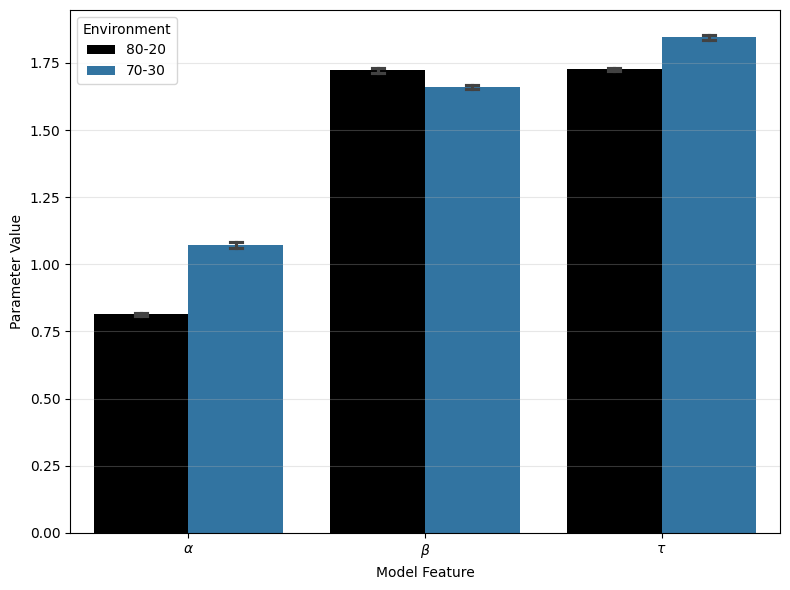

In [ ]:
df_params = cv_results.melt(
    id_vars=["Condition", "Fold", "Test_LL"],
    value_vars=["Alpha", "Beta", "Tau"],
    var_name="Parameter",
    value_name="Value",
)

df_params["Parameter"] = df_params["Parameter"].replace(
    {"Alpha": r"$\alpha$", "Beta": r"$\beta$", "Tau": r"$\tau$"}
)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_params,
    x="Parameter",
    y="Value",
    hue="Condition",
    palette=["black", "tab:blue"],
    capsize=0.1,
    errorbar="se",
)

plt.ylabel("Parameter Value")
plt.xlabel("Model Feature")
plt.legend(title="Environment")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "Parameter Shift.pdf"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
def get_switch_prob_around_transition(sessions, targets, window_pre=3, window_post=5):
    aligned_switches = {i: [] for i in range(-window_pre, window_post + 1)}

    for (choices, _), states in zip(sessions, targets):
        # Find transition indices
        transitions = np.where(np.abs(np.diff(states)) > 0)[0] + 1

        # Calculate switch array (1 if switched from prev, 0 if stay)
        did_switch = np.abs(np.diff(choices))
        did_switch = np.insert(did_switch, 0, 0)

        for t_idx in transitions:
            for rel_t in range(-window_pre, window_post + 1):
                abs_t = t_idx + rel_t
                if 0 <= abs_t < len(choices):
                    aligned_switches[rel_t].append(did_switch[abs_t])

    # Safely compute Average and Standard Error
    x = sorted(aligned_switches.keys())
    y, err = [], []
    for k in x:
        vals = aligned_switches[k]
        if len(vals) > 1:
            y.append(np.mean(vals))
            err.append(sem(vals))
        elif len(vals) == 1:
            y.append(np.mean(vals))
            err.append(0.0)
        else:
            y.append(np.nan)
            err.append(np.nan)

    return x, y, err

Figure 1: Cross-environmental validation of switch dynamics and the behavioral failure of static stickiness. Upper panel: The circles with $1\sigma$ uncertainties represent empirical observations of the port-switching probability $p(\text{switching})$ from mice navigating a 70-30 switching bandit task. The curves represent simulated distributions obtained from generative RFLR models across identical trial sequences. The RFLR model parameterized for the 80-20 environment (crimson dashed) systematically overestimates the baseline probability of switching and reacts prematurely to environmental noise. Conversely, the RFLR model refitted with environment-specific 70-30 parameters (blue solid) successfully approximates the biological cognitive lag. Lower panel: Model residuals with respect to the observational data, quoted relative to the $1\sigma$ uncertainty (Standard Error of the Mean) on each empirical data point, calculated as $(p_{model} - p_{data}) / \sigma$. The baseline (solid black) represents the empirical mean at $y=0$. 

The 80-20 model consistently diverges by multiple standard deviations from the empirical baseline, proving that a static parameter cannot generalize across environments of varying volatility.

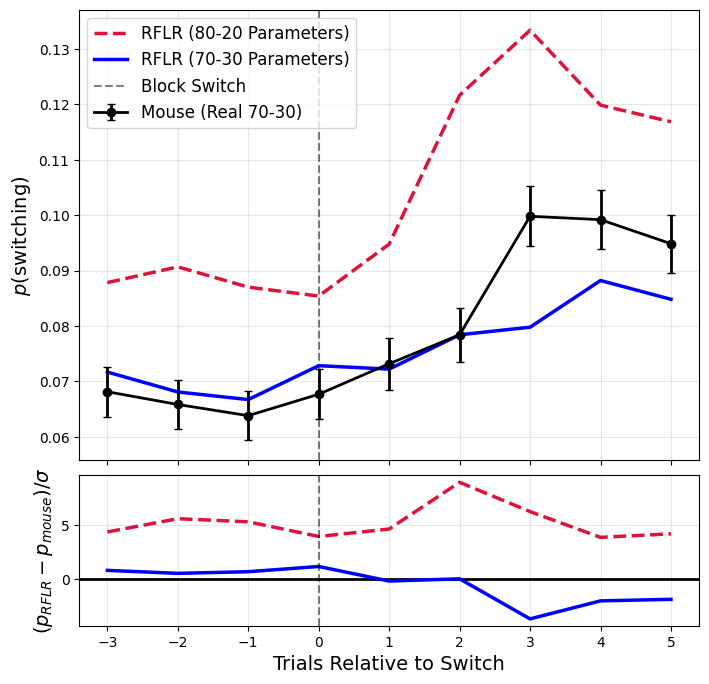

In [ ]:
# Set up a figure with 2 rows, 1 column.
# gridspec_kw sets the height ratio so the top plot is larger than the bottom plot.
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
fig.subplots_adjust(hspace=0.05)  # Removes the space between the panels

# 1. Extract the Baseline (Real Mouse) Data First for Residuals
x_axis, y_mouse, err_mouse = get_switch_prob_around_transition(sess_70, targ_70)
y_mouse = np.array(y_mouse)
err_mouse = np.array(err_mouse)

# Plot Mouse baseline on bottom panel (y=0 is now SOLID BLACK)
ax2.axhline(0, color="black", linestyle="-", lw=2)

# 2. Define all lines: (Legend Name, Data, Color, Line Style, Line Width)
models = [
    ("Mouse (Real 70-30)", sess_70, "black", "-", 2),
    ("RFLR (80-20 Parameters)", sim_rflr_70_old_parameters, "crimson", "--", 2.5),
    ("RFLR (70-30 Parameters)", sim_rflr_70, "blue", "-", 2.5),
]

# 3. Plot each model differently based on if it is empirical data or a simulation
for name, data, col, ls, lw in models:
    x, y, err = get_switch_prob_around_transition(data, targ_70)

    if "Mouse" in name:
        # Plot Empirical Data: Points + Error Bars
        ax1.errorbar(
            x,
            y,
            yerr=err,
            label=name,
            color=col,
            linestyle=ls,
            capsize=3,
            lw=lw,
            marker="o",
            markersize=6,
            zorder=5,
        )
    else:
        # Plot Theoretical Models: Clean Lines
        ax1.plot(x, y, label=name, color=col, linestyle=ls, lw=lw, zorder=4)

        # Bottom Panel: STANDARDIZED Residual Plot (Model - Mouse) / Sigma
        residuals = (np.array(y) - y_mouse) / (err_mouse)

        # Plot the standardized line difference
        ax2.plot(x, residuals, color=col, linestyle=ls, lw=lw)

# 3. Formatting Top Panel (ax1)
ax1.axvline(0, color="k", linestyle="--", alpha=0.5, label="Block Switch")
ax1.set_ylabel(r"$p$(switching)", fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left", fontsize=12)

# 4. Formatting Bottom Panel (ax2)
ax2.axvline(0, color="k", linestyle="--", alpha=0.5)
ax2.set_xlabel("Trials Relative to Switch", fontsize=14)
# Updated y-axis label to match the math: (Model - Data) / Sigma
ax2.set_ylabel(r"$(p_{RFLR} - p_{mouse}) / \sigma$", fontsize=14)
ax2.grid(True, alpha=0.3)

plt.savefig(os.path.join(fig_dir, "Switch_Dynamics.pdf"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
def calc_metrics(sessions_list, label):
    data = []
    for c, r in sessions_list:
        n_switches = np.sum(np.abs(np.diff(c)))
        tot_reward = np.sum(r)
        data.append({"Model": label, "Switches": n_switches, "Reward": tot_reward})
    return pd.DataFrame(data)

In [ ]:
df_metrics_80 = pd.concat(
    [
        calc_metrics(sess_80, "Mouse (Real)"),
        calc_metrics(sim_rflr_80, "RFLR (Static)"),
        calc_metrics(sim_sticky_80, "Sticky HMM (Static)"),
        calc_metrics(sim_ideal_80, "Ideal HMM (Static)"),
    ]
)
df_metrics_70 = pd.concat(
    [
        calc_metrics(sess_70, "Mouse (Real)"),
        calc_metrics(sim_rflr_70, "RFLR (Static)"),
        calc_metrics(sim_sticky_70, "Sticky HMM (Static)"),
        calc_metrics(sim_ideal_70, "Ideal HMM (Static)"),
    ]
)

In [56]:
df_70 = df_metrics_70.copy()
df_70["Condition"] = "70-30"

df_80 = df_metrics_80.copy()
df_80["Condition"] = "80-20"

# Combine into one DataFrame
df_combined = pd.concat([df_70, df_80], ignore_index=True)

Figure 2: The behavioral efficiency frontier comparing total session reward against the cognitive cost of switching. The circles represent data aggregated from the 70-30 environment, while the crosses represent the 80-20 environment. Small translucent markers denote individual sessions, and large opaque markers denote the condition centroids for each respective model.

Efficiency: In the highly volatile 70-30 condition, empirical mice (black) accept a lower total reward but strictly maintain a low switching rate.

The Failure of Ideal HMM: The Ideal HMM (blue) proves highly inefficient in the 70-30 condition. Lacking "stickiness," it interprets probabilistic noise as environmental transitions, resulting in a massive increase in switching cost that is not present in biological data.

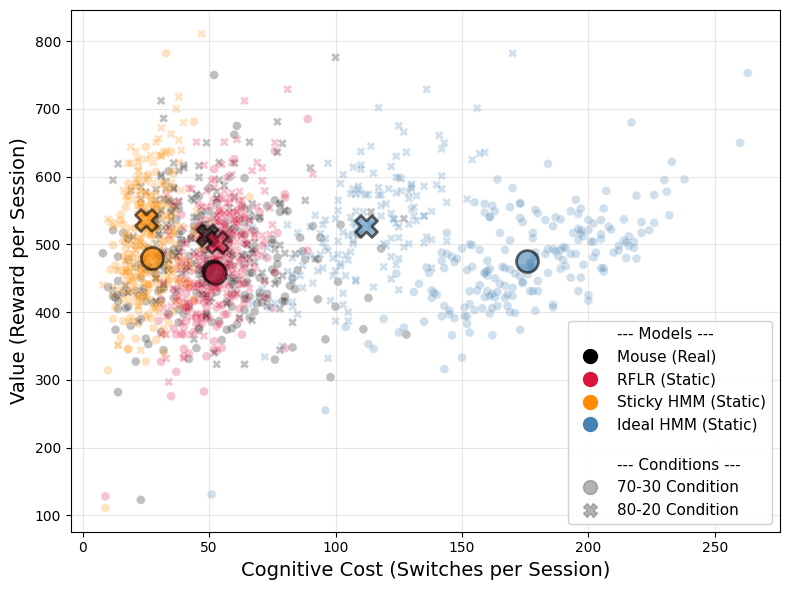

In [ ]:
model_order = [
    "Mouse (Real)",
    "RFLR (Static)",
    "Sticky HMM (Static)",
    "Ideal HMM (Static)",
]

model_colors = {
    "Mouse (Real)": "black",  # Solid baseline
    "RFLR (Static)": "crimson",  # Deep, distinct red
    "Sticky HMM (Static)": "darkorange",  # Vibrant orange
    "Ideal HMM (Static)": "steelblue",  # Cool blue
}

condition_markers = {"70-30": "o", "80-20": "X"}  # Circle  # Cross

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot for all the background session points
sns.scatterplot(
    data=df_combined,
    x="Switches",
    y="Reward",
    hue="Model",
    style="Condition",
    palette=model_colors,
    markers=condition_markers,
    alpha=0.25,
    s=40,
    ax=ax,
    legend=False,
)

# Calculate and plot the large centroids (Means)
centroids = (
    df_combined.groupby(["Condition", "Model"])[["Switches", "Reward"]]
    .mean()
    .reset_index()
)

for _, row in centroids.iterrows():
    ax.scatter(
        row["Switches"],
        row["Reward"],
        s=250,  # Make the mean highly visible
        color=model_colors[row["Model"]],
        marker=condition_markers[row["Condition"]],
        linewidth=2,
        zorder=5,
        edgecolors="black",
        alpha=0.6,
    )

# Formatting
ax.set_xlabel("Cognitive Cost (Switches per Session)", fontsize=14)
ax.set_ylabel("Value (Reward per Session)", fontsize=14)
ax.grid(True, alpha=0.3)

# Custom Legend (To clearly separate Color=Model and Shape=Condition)
legend_elements = [mlines.Line2D([], [], color="none", label="--- Models ---")]
for model in model_order:
    legend_elements.append(
        mlines.Line2D(
            [],
            [],
            color=model_colors[model],
            marker="o",
            linestyle="None",
            markersize=10,
            label=model,
        )
    )

legend_elements.append(
    mlines.Line2D([], [], color="none", label="\n--- Conditions ---")
)
legend_elements.append(
    mlines.Line2D(
        [],
        [],
        color="gray",
        marker="o",
        linestyle="None",
        markersize=10,
        label="70-30 Condition",
        alpha=0.6,
    )
)
legend_elements.append(
    mlines.Line2D(
        [],
        [],
        color="gray",
        marker="X",
        linestyle="None",
        markersize=10,
        label="80-20 Condition",
        alpha=0.6,
    )
)

ax.legend(handles=legend_elements, loc="lower right", framealpha=0.9, fontsize=11)

plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, "Reward_vs_Cognitive_Cost.pdf"), dpi=300, bbox_inches="tight"
)
plt.show()

In [ ]:
df_combined["Reward_Per_Switch"] = df_combined["Reward"] / df_combined["Switches"].clip(
    lower=1
)

color_map = {
    "Mouse (Real)": "black",
    "RFLR (Static)": "tab:red",
    "Sticky HMM (Static)": "tab:green",
    "Ideal HMM (Static)": "tab:blue",
}
style_map = {"70-30": "o", "80-20": "X"}

fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(
    data=df_combined,
    x="Switches",
    y="Reward_Per_Switch",
    hue="Model",
    style="Condition",
    markers=style_map,
    palette=color_map,
    alpha=0.4,
    ax=ax,
    legend=False,
)

centroids = (
    df_combined.groupby(["Condition", "Model"])[["Switches", "Reward_Per_Switch"]]
    .mean()
    .reset_index()
)
for _, row in centroids.iterrows():
    marker = style_map[row["Condition"]]
    ax.scatter(
        row["Switches"],
        row["Reward_Per_Switch"],
        s=250,
        marker=marker,
        color=color_map[row["Model"]],
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )

model_handles = [
    mlines.Line2D([], [], color=c, marker="o", linestyle="None", markersize=8, label=m)
    for m, c in color_map.items()
]
cond_handles = [
    mlines.Line2D(
        [], [], color="grey", marker=v, linestyle="None", markersize=8, label=k
    )
    for k, v in style_map.items()
]
ax.legend(
    handles=model_handles + cond_handles, loc="upper right", framealpha=0.9, fontsize=10
)

ax.set_xlabel("Switches per Session", fontsize=13)
ax.set_ylabel("Reward per Switch", fontsize=13)
ax.set_title("Switches vs Reward per Switch (70-30 and 80-20)", fontsize=14)
sns.despine()
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, "scatter_switches_vs_reward_per_switch.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()